# "The error bars overlap, so it is not significant"

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/ci-overlap-fallacy/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/ci-overlap-fallacy/demo.ipynb)

For two independent means, 95% bars that do not touch imply `p < 0.05`. The converse is false:
**a large share of real, significant results have overlapping bars.** Read as a test, the overlap
rule has a size of about 0.6%, not 5%. On paired data it fails the other way.

1. The geometry - exact
2. Calibration - the theorem, checked before any result is read
3. The dead zone - measured
4. The reversal on paired data - measured
5. The bars themselves - exact coverage of four proportion intervals
6. Try your own

## The engine

Extracted from `overlap.py` at build time, character for character, so this notebook runs from a
bare Colab link with nothing else installed beyond numpy, scipy and matplotlib.

In [1]:
from __future__ import annotations

import math
from typing import Dict, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

ALPHA = 0.05


Z99 = 2.5758293035489004


CHUNK = 4000


BAND_LO, BAND_HI = 0.045, 0.055


def wilson(rate: float, n: int, z: float = Z99) -> Tuple[float, float]:
    """Wilson score interval for a measured proportion - used for every rate verdict here."""
    if n <= 0:
        return (0.0, 1.0)
    denom = 1.0 + z * z / n
    centre = (rate + z * z / (2.0 * n)) / denom
    half = z * math.sqrt(rate * (1.0 - rate) / n + z * z / (4.0 * n * n)) / denom
    return max(0.0, centre - half), min(1.0, centre + half)


def mc_interval(values: np.ndarray, z: float = Z99) -> Tuple[float, float]:
    """99% interval on a Monte Carlo mean, so no 'difference' is read off two point estimates."""
    m = float(values.mean())
    se = float(values.std(ddof=1) / math.sqrt(values.size))
    return m - z * se, m + z * se


def verdict(rate: float, n: int) -> str:
    """INFLATED / CONSERVATIVE / ok - the whole interval must clear the band, or it is ok."""
    lo, hi = wilson(rate, n)
    if lo > BAND_HI:
        return "INFLATED"
    if hi < BAND_LO:
        return "CONSERVATIVE"
    return "ok"


def z_for_level(level: float) -> float:
    """Two-sided normal multiplier for a confidence level, e.g. 0.95 -> 1.959964."""
    return float(stats.norm.ppf(0.5 + level / 2.0))


def level_for_z(z: float) -> float:
    return float(2.0 * stats.norm.cdf(z) - 1.0)


Z_ALPHA = z_for_level(1.0 - ALPHA)


def se_ratio(s1: float, s2: float) -> float:
    """R = (s1 + s2) / sqrt(s1^2 + s2^2). The single number the whole fallacy turns on.

    Bounded in [1, sqrt(2)]: sqrt(2) when the two standard errors are equal, approaching 1 as
    one of them dominates. It is exactly the factor by which the non-overlap threshold exceeds
    the significance threshold at a common multiplier.
    """
    if s1 < 0 or s2 < 0 or (s1 == 0 and s2 == 0):
        raise ValueError("standard errors must be non-negative and not both zero")
    return (s1 + s2) / math.sqrt(s1 * s1 + s2 * s2)


def matching_level(s1: float, s2: float, alpha: float = ALPHA) -> float:
    """The confidence level whose non-overlap event IS the alpha-level test's rejection event.

    Solve z * (s1 + s2) = z_alpha * sqrt(s1^2 + s2^2)  ->  z = z_alpha / R.
    At equal standard errors this is z_alpha / sqrt(2) = 1.3859, i.e. 83.4% intervals - which
    is why "83% error bars" keeps turning up in the methods sections of people who have thought
    about this, and why it is never 95%.
    """
    return level_for_z(z_for_level(1.0 - alpha) / se_ratio(s1, s2))


MATCHING_LEVEL_EQUAL_SE = matching_level(1.0, 1.0)


def overlap_fraction_at_significance(s1: float, s2: float, level: float = 0.95,
                                     alpha: float = ALPHA) -> float:
    """How much of an arm the bars may still share while the test is exactly at its boundary.

    Overlap is measured as a fraction of the MEAN arm length (an arm being one half-width):

        f = overlap_length / ((arm1 + arm2) / 2)

    At the significance boundary d = z_alpha * sqrt(s1^2 + s2^2), so

        f = 2 - 2 * z_alpha / (z_level * R)

    which is 2 - sqrt(2) = 0.5858 for equal standard errors and 95% bars, and falls to 0 as the
    standard errors diverge. There is no universal "a bit of overlap is fine" number: the
    permitted overlap is a function of the design, not of the picture.
    """
    return 2.0 - 2.0 * z_for_level(1.0 - alpha) / (z_for_level(level) * se_ratio(s1, s2))


def rule_alpha(s1: float, s2: float, level: float = 0.95) -> float:
    """The false-positive rate of the OVERLAP RULE itself, read as a test.

    Under a true null the difference is `N(0, sqrt(s1^2 + s2^2))`, and the rule fires when
    `|d| > z_level * (s1 + s2)`. So the rule is a two-sided test at `z_level * R` standard
    errors, and its size is `2 * (1 - Phi(z_level * R))`. At equal standard errors and 95% bars
    that is 0.0056 - the rule is a 0.6% test wearing a 5% label, which is the whole dead zone
    restated in one number.
    """
    return float(2.0 * stats.norm.sf(z_for_level(level) * se_ratio(s1, s2)))


def paired_se(s1: float, s2: float, rho: float) -> float:
    """SE of the difference when the two estimates are correlated. The bars cannot show rho."""
    v = s1 * s1 + s2 * s2 - 2.0 * rho * s1 * s2
    return math.sqrt(max(v, 0.0))


RULE_ALPHA_EQUAL_SE = rule_alpha(1.0, 1.0)


def paired_slack(s1: float, s2: float, rho: float, level: float = 0.95,
                 alpha: float = ALPHA) -> float:
    """How many times further apart the bars demand the means be than the test does.

    Above 1 the rule is conservative (it discards real results); it rises without bound as rho
    approaches 1. This is the number the independent-groups algebra caps at sqrt(2) and that
    correlation removes the cap from.
    """
    se = paired_se(s1, s2, rho)
    if se <= 0:
        return float("inf")
    return z_for_level(level) * (s1 + s2) / (z_for_level(1.0 - alpha) * se)


def overlaps(lo_a: float, hi_a: float, lo_b: float, hi_b: float) -> bool:
    return (lo_a <= hi_b) and (lo_b <= hi_a)


def overlap_share(lo_a: np.ndarray, hi_a: np.ndarray, lo_b: np.ndarray,
                  hi_b: np.ndarray) -> np.ndarray:
    """Vectorised overlap length as a fraction of the mean arm. Negative means a visible gap."""
    inter = np.minimum(hi_a, hi_b) - np.maximum(lo_a, lo_b)
    mean_arm = ((hi_a - lo_a) + (hi_b - lo_b)) / 4.0
    return inter / mean_arm


def ci_known_sigma(mean: np.ndarray, se: float, level: float = 0.95
                   ) -> Tuple[np.ndarray, np.ndarray]:
    z = z_for_level(level)
    return mean - z * se, mean + z * se


def ci_t(mean: np.ndarray, sd: np.ndarray, n: int, level: float = 0.95
         ) -> Tuple[np.ndarray, np.ndarray]:
    t = float(stats.t.ppf(0.5 + level / 2.0, n - 1))
    half = t * sd / math.sqrt(n)
    return mean - half, mean + half


def welch_p(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Two-sided Welch p-value, rows are replicates. The test is never the thing at fault here."""
    n1, n2 = a.shape[1], b.shape[1]
    m1, m2 = a.mean(axis=1), b.mean(axis=1)
    v1, v2 = a.var(axis=1, ddof=1), b.var(axis=1, ddof=1)
    se2 = v1 / n1 + v2 / n2
    t = (m1 - m2) / np.sqrt(se2)
    df = se2 ** 2 / (v1 ** 2 / (n1 ** 2 * (n1 - 1)) + v2 ** 2 / (n2 ** 2 * (n2 - 1)))
    return 2.0 * stats.t.sf(np.abs(t), df)


def z_test_p(a: np.ndarray, b: np.ndarray, sd1: float, sd2: float) -> np.ndarray:
    """Two-sided z-test using the SAME known standard errors the bars are drawn from.

    This exists to make the containment theorem checkable as an exact logical statement. The
    theorem is about intervals and a test that share their standard errors; the moment the bars
    are drawn from one SE and the test computed from another, it is no longer guaranteed - which
    is measured, not assumed, in `run_means(..., test="welch", known_sigma=True)`.
    """
    n1, n2 = a.shape[1], b.shape[1]
    se = math.sqrt(sd1 * sd1 / n1 + sd2 * sd2 / n2)
    z = (a.mean(axis=1) - b.mean(axis=1)) / se
    return 2.0 * stats.norm.sf(np.abs(z))


def paired_p(d: np.ndarray) -> np.ndarray:
    """Two-sided paired t-test on the differences, rows are replicates."""
    n = d.shape[1]
    t = d.mean(axis=1) / (d.std(axis=1, ddof=1) / math.sqrt(n))
    return 2.0 * stats.t.sf(np.abs(t), n - 1)


def _chunks(reps: int, size: int = CHUNK) -> List[int]:
    out = []
    left = reps
    while left > 0:
        out.append(min(size, left))
        left -= size
    return out


def run_means(n1: int, n2: int, sd1: float, sd2: float, delta: float, reps: int, seed: int,
              level: float = 0.95, known_sigma: bool = False,
              test: str = "welch") -> Dict[str, float]:
    """One design, replicated. Returns the rates the whole argument is made of.

    `sig` is the Welch t-test. `gap` is the reader's rule: the two intervals do not touch.
    `sig_and_overlap` is the dead zone - a real result the picture tells you to discard.
    `gap_and_not_sig` is the reverse failure, which the algebra forbids for known-sigma
    intervals and does NOT forbid once each group gets its own t multiplier.
    """
    rng = np.random.default_rng(seed)
    sig = gap = both = sig_ov = gap_ns = 0
    shares: List[np.ndarray] = []
    for m in _chunks(reps):
        a = rng.normal(0.0, sd1, size=(m, n1))
        b = rng.normal(delta, sd2, size=(m, n2))
        p = z_test_p(a, b, sd1, sd2) if test == "z" else welch_p(a, b)
        if known_sigma:
            lo_a, hi_a = ci_known_sigma(a.mean(axis=1), sd1 / math.sqrt(n1), level)
            lo_b, hi_b = ci_known_sigma(b.mean(axis=1), sd2 / math.sqrt(n2), level)
        else:
            lo_a, hi_a = ci_t(a.mean(axis=1), a.std(axis=1, ddof=1), n1, level)
            lo_b, hi_b = ci_t(b.mean(axis=1), b.std(axis=1, ddof=1), n2, level)
        share = overlap_share(lo_a, hi_a, lo_b, hi_b)
        is_sig = p < ALPHA
        is_gap = share < 0.0
        sig += int(is_sig.sum())
        gap += int(is_gap.sum())
        both += int((is_sig & is_gap).sum())
        sig_ov += int((is_sig & ~is_gap).sum())
        gap_ns += int((is_gap & ~is_sig).sum())
        shares.append(share[is_sig])
    sig_shares = np.concatenate(shares) if shares else np.array([0.0])
    return {
        "n1": n1, "n2": n2, "sd1": sd1, "sd2": sd2, "delta": delta, "level": level,
        "reps": reps, "known_sigma": known_sigma, "test": test,
        "sig": sig / reps,
        "gap": gap / reps,
        "sig_and_overlap": sig_ov / reps,
        "gap_and_not_sig": gap_ns / reps,
        "disagree": (sig_ov + gap_ns) / reps,
        "overlap_given_sig": (sig_ov / sig) if sig else float("nan"),
        "median_share_when_sig": float(np.median(sig_shares)) if sig else float("nan"),
        "se_ratio": se_ratio(sd1 / math.sqrt(n1), sd2 / math.sqrt(n2)),
        "matching_level": matching_level(sd1 / math.sqrt(n1), sd2 / math.sqrt(n2)),
    }


def run_paired(n: int, rho: float, delta: float, sd: float, reps: int,
               seed: int, level: float = 0.95) -> Dict[str, float]:
    """The reversal. Bars are drawn per arm, as they always are; the test knows about rho."""
    rng = np.random.default_rng(seed)
    sig = sig_ov = 0
    for m in _chunks(reps):
        z1 = rng.normal(0.0, 1.0, size=(m, n))
        z2 = rho * z1 + math.sqrt(max(1.0 - rho * rho, 0.0)) * rng.normal(0.0, 1.0, size=(m, n))
        a = sd * z1
        b = delta + sd * z2
        p = paired_p(b - a)
        lo_a, hi_a = ci_t(a.mean(axis=1), a.std(axis=1, ddof=1), n, level)
        lo_b, hi_b = ci_t(b.mean(axis=1), b.std(axis=1, ddof=1), n, level)
        share = overlap_share(lo_a, hi_a, lo_b, hi_b)
        is_sig = p < ALPHA
        sig += int(is_sig.sum())
        sig_ov += int((is_sig & (share >= 0.0)).sum())
    se = sd / math.sqrt(n)
    return {
        "n": n, "rho": rho, "delta": delta, "reps": reps,
        "sig": sig / reps,
        "sig_and_overlap": sig_ov / reps,
        "overlap_given_sig": (sig_ov / sig) if sig else float("nan"),
        "slack": paired_slack(se, se, rho, level),
    }


METHODS = ("wald", "wilson", "agresti_coull", "clopper_pearson")


def prop_ci(method: str, x: np.ndarray, n: int, level: float = 0.95
            ) -> Tuple[np.ndarray, np.ndarray]:
    """Interval for a binomial proportion. x may be an array of counts."""
    x = np.asarray(x, dtype=float)
    z = z_for_level(level)
    if method == "wald":
        p = x / n
        half = z * np.sqrt(p * (1.0 - p) / n)
        return np.clip(p - half, 0.0, 1.0), np.clip(p + half, 0.0, 1.0)
    if method == "wilson":
        p = x / n
        denom = 1.0 + z * z / n
        centre = (p + z * z / (2.0 * n)) / denom
        half = z * np.sqrt(p * (1.0 - p) / n + z * z / (4.0 * n * n)) / denom
        return np.clip(centre - half, 0.0, 1.0), np.clip(centre + half, 0.0, 1.0)
    if method == "agresti_coull":
        n_t = n + z * z
        p_t = (x + z * z / 2.0) / n_t
        half = z * np.sqrt(p_t * (1.0 - p_t) / n_t)
        return np.clip(p_t - half, 0.0, 1.0), np.clip(p_t + half, 0.0, 1.0)
    if method == "clopper_pearson":
        a = 1.0 - level
        lo = np.where(x > 0, stats.beta.ppf(a / 2.0, x, n - x + 1), 0.0)
        hi = np.where(x < n, stats.beta.ppf(1.0 - a / 2.0, x + 1, n - x), 1.0)
        return np.nan_to_num(lo, nan=0.0), np.nan_to_num(hi, nan=1.0)
    raise ValueError(f"unknown method {method!r}")


def exact_coverage(method: str, p: float, n: int, level: float = 0.95) -> float:
    """Exact coverage: enumerate every count 0..n and weight by its binomial probability."""
    x = np.arange(n + 1)
    lo, hi = prop_ci(method, x, n, level)
    w = stats.binom.pmf(x, n, p)
    return float(w[(lo <= p) & (p <= hi)].sum())


def exact_interval_width(method: str, p: float, n: int, level: float = 0.95) -> float:
    x = np.arange(n + 1)
    lo, hi = prop_ci(method, x, n, level)
    return float((stats.binom.pmf(x, n, p) * (hi - lo)).sum())


def two_prop_z(x1: np.ndarray, n1: int, x2: np.ndarray, n2: int) -> np.ndarray:
    """Pooled two-proportion z statistic. Its SE is NOT the one the two bars are drawn from,
    which is why the containment theorem can fail here and cannot fail for two means."""
    p1, p2 = x1 / n1, x2 / n2
    pool = (x1 + x2) / (n1 + n2)
    se = np.sqrt(pool * (1.0 - pool) * (1.0 / n1 + 1.0 / n2))
    with np.errstate(divide="ignore", invalid="ignore"):
        z = np.where(se > 0, (p1 - p2) / np.where(se > 0, se, 1.0), 0.0)
    return z


def exact_prop_rule(method: str, p1: float, p2: float, n1: int, n2: int,
                    level: float = 0.95) -> Dict[str, float]:
    """Every outcome pair, exactly weighted. Returns the two rule failures and the test's rate."""
    x1 = np.arange(n1 + 1)[:, None]
    x2 = np.arange(n2 + 1)[None, :]
    w = stats.binom.pmf(x1, n1, p1) * stats.binom.pmf(x2, n2, p2)
    lo1, hi1 = prop_ci(method, np.arange(n1 + 1), n1, level)
    lo2, hi2 = prop_ci(method, np.arange(n2 + 1), n2, level)
    gap = (lo1[:, None] > hi2[None, :]) | (lo2[None, :] > hi1[:, None])
    z = two_prop_z(x1, n1, x2, n2)
    sig = 2.0 * stats.norm.sf(np.abs(z)) < ALPHA
    return {
        "method": method, "p1": p1, "p2": p2, "n1": n1, "n2": n2,
        "sig": float(w[sig].sum()),
        "gap": float(w[gap].sum()),
        "sig_and_overlap": float(w[sig & ~gap].sum()),
        "gap_and_not_sig": float(w[gap & ~sig].sum()),
    }


MEANS_REPS = 40_000


PAIRED_REPS = 40_000


CONTAINMENT_REPS = 200_000


MEANS_DESIGNS: List[Tuple[int, int, float, float, float]] = [
    (30, 30, 1.0, 1.0, 0.60),
    (30, 30, 1.0, 1.0, 0.80),
    (30, 30, 1.0, 1.0, 1.00),
    (60, 60, 1.0, 1.0, 0.45),
    (60, 60, 1.0, 1.0, 0.60),
    (100, 100, 1.0, 1.0, 0.40),
    (30, 30, 1.0, 3.0, 1.60),
    (30, 30, 1.0, 6.0, 3.00),
    (100, 20, 1.0, 1.0, 0.70),
    (100, 20, 1.0, 3.0, 2.20),
    (20, 20, 1.0, 1.0, 1.00),
    (200, 200, 1.0, 1.0, 0.28),
]


CONTAINMENT_DESIGNS: List[Tuple[int, int, float, float, float]] = [
    (30, 30, 1.0, 1.0, 0.70),
    (100, 20, 1.0, 1.0, 0.70),
    (100, 5, 1.0, 1.0, 1.20),
    (200, 6, 1.0, 2.5, 2.40),
    (40, 8, 1.0, 1.0, 1.00),
]


RATIO_GRID: List[float] = [1.0, 1.25, 1.5, 2.0, 3.0, 5.0, 10.0, 30.0]


RHO_GRID: List[float] = [0.0, 0.3, 0.5, 0.7, 0.85, 0.95]


PAIRED_N = 30


PAIRED_DELTA = 0.35


PAIRED_SD = 1.0


COVERAGE_PS: List[float] = [0.02, 0.05, 0.10, 0.25, 0.50]


COVERAGE_NS: List[int] = [20, 50, 100, 400]


PROP_DESIGNS: List[Tuple[float, float, int, int]] = [
    (0.50, 0.62, 100, 100),
    (0.10, 0.18, 200, 200),
    (0.03, 0.08, 150, 150),
    (0.50, 0.66, 60, 60),
    (0.20, 0.34, 80, 80),
]


MEANS_SEED_BASE = 71_000


CONTAINMENT_SEED_BASE = 72_000


PAIRED_SEED_BASE = 73_000


LEVEL_SEED_BASE = 74_000


def delta_for_power(n1: int, n2: int, sd1: float, sd2: float, power: float = 0.80) -> float:
    """Normal-approximation delta hitting a target power. Used only to LABEL designs."""
    se = math.sqrt(sd1 * sd1 / n1 + sd2 * sd2 / n2)
    return (Z_ALPHA + z_for_level(2.0 * power - 1.0)) * se


def approx_power(n1: int, n2: int, sd1: float, sd2: float, delta: float) -> float:
    se = math.sqrt(sd1 * sd1 / n1 + sd2 * sd2 / n2)
    lam = delta / se
    return float(stats.norm.sf(Z_ALPHA - lam) + stats.norm.cdf(-Z_ALPHA - lam))


def geometry_table(ratios: Sequence[float] = tuple(RATIO_GRID)) -> List[Dict[str, float]]:
    """Closed-form only: what the two rules demand, as the standard errors diverge."""
    rows = []
    for r in ratios:
        s1, s2 = 1.0, float(r)
        rows.append({
            "sd_ratio": float(r),
            "se_ratio": se_ratio(s1, s2),
            "matching_level": matching_level(s1, s2),
            "overlap_at_sig": overlap_fraction_at_significance(s1, s2),
            "threshold_inflation": se_ratio(s1, s2),
        })
    return rows

print('engine loaded')

engine loaded


## 1. The geometry - exact

Two estimates with standard errors `s1`, `s2`. The bars separate when `|d| > z(s1 + s2)`; the test
rejects when `|d| > z_alpha * sqrt(s1^2 + s2^2)`. Since `s1 + s2 >= sqrt(s1^2 + s2^2)`, non-overlap
is always the stricter event - by a factor of `sqrt(2)` at equal standard errors.

In [2]:
print(f"matching level at equal SE : {matching_level(1, 1) * 100:.1f}%   (not 95%)")
print(f"overlap allowed at p = 0.05: {overlap_fraction_at_significance(1, 1) * 100:.1f}% of an arm")
print(f"size of the overlap rule   : {rule_alpha(1, 1):.4f}   (labelled 0.05)")
print()
print("  sd ratio   threshold x   matching level   overlap still allowed")
for g in geometry_table():
    print(f"  {g['sd_ratio']:>8.2f}   {g['se_ratio']:>11.4f}   {g['matching_level'] * 100:>13.1f}%"
          f"   {g['overlap_at_sig'] * 100:>10.1f}%")

matching level at equal SE : 83.4%   (not 95%)
overlap allowed at p = 0.05: 58.6% of an arm
size of the overlap rule   : 0.0056   (labelled 0.05)

  sd ratio   threshold x   matching level   overlap still allowed
      1.00        1.4142            83.4%         58.6%
      1.25        1.4056            83.7%         57.7%
      1.50        1.3868            84.2%         55.8%
      2.00        1.3416            85.6%         50.9%
      3.00        1.2649            87.9%         41.9%
      5.00        1.1767            90.4%         30.0%
     10.00        1.0945            92.7%         17.3%
     30.00        1.0328            94.2%          6.3%


The rule is **worst** at a ratio of 1 - two groups of the same size and spread, the design everyone
trusts. "A little overlap is fine" has no single number: it runs from 58.6% of an arm to near zero.

## 2. Calibration - the theorem, checked first

If the bars and the test share their standard errors, "bars apart" must imply "significant" with
no exceptions. Any violation would mean the harness is broken. Then break the premise on purpose:
same bars, but test with the observed variance (Welch).

*This notebook runs 8,000 replicates per design against the study's 200,000, using the same
seeds - so these rows are the first slice of the evidence file's sample. Lower counts widen every
interval; that is the resolution of the instrument, not a disagreement with `evidence.txt`.*

In [3]:
NB_REPS = 8000
print("  design          shared-SE violations   Welch violations")
for i, (n1, n2, s1, s2, d) in enumerate(CONTAINMENT_DESIGNS):
    a = run_means(n1, n2, s1, s2, d, NB_REPS, CONTAINMENT_SEED_BASE + i, known_sigma=True, test="z")
    b = run_means(n1, n2, s1, s2, d, NB_REPS, CONTAINMENT_SEED_BASE + 100 + i, known_sigma=True)
    print(f"  {n1:>3}/{n2:<3} sd {s1}/{s2:<4}  {a['gap_and_not_sig']:>12.5f}   {b['gap_and_not_sig']:>16.5f}")

  design          shared-SE violations   Welch violations
   30/30  sd 1.0/1.0        0.00000            0.00000
  100/20  sd 1.0/1.0        0.00000            0.00125
  100/5   sd 1.0/1.0        0.00000            0.14863
  200/6   sd 1.0/2.5        0.00000            0.17550
   40/8   sd 1.0/1.0        0.00000            0.02650


## 3. The dead zone - measured

95% t-intervals per group, Welch test at 0.05, normal data. `P(overlap | sig)` is the share of real,
significant results that a reader applying the overlap rule would throw away.

In [4]:
dead = []
for i, (n1, n2, s1, s2, d) in enumerate(MEANS_DESIGNS):
    r = run_means(n1, n2, s1, s2, d, NB_REPS, MEANS_SEED_BASE + i)
    dead.append(r)
    print(f"  {n1:>3}/{n2:<3} sd {s1:g}/{s2:<3g}  P(sig) {r['sig']:.3f}   P(overlap | sig) {r['overlap_given_sig']:.3f}")

   30/30  sd 1/1    P(sig) 0.628   P(overlap | sig) 0.531
   30/30  sd 1/1    P(sig) 0.857   P(overlap | sig) 0.311
   30/30  sd 1/1    P(sig) 0.968   P(overlap | sig) 0.142
   60/60  sd 1/1    P(sig) 0.686   P(overlap | sig) 0.473
   60/60  sd 1/1    P(sig) 0.902   P(overlap | sig) 0.251
  100/100 sd 1/1    P(sig) 0.799   P(overlap | sig) 0.354
   30/30  sd 1/3    P(sig) 0.768   P(overlap | sig) 0.244
   30/30  sd 1/6    P(sig) 0.745   P(overlap | sig) 0.143
  100/20  sd 1/1    P(sig) 0.782   P(overlap | sig) 0.282
  100/20  sd 1/3    P(sig) 0.870   P(overlap | sig) 0.069
   20/20  sd 1/1    P(sig) 0.861   P(overlap | sig) 0.318
  200/200 sd 1/1    P(sig) 0.800   P(overlap | sig) 0.365


## 4. The reversal on paired data

Pair the measurements and the test uses the correlation; the per-arm bars cannot show it. The
same picture now hides an overwhelming difference behind two bars sitting on top of each other.

In [5]:
paired = []
for i, rho in enumerate(RHO_GRID):
    r = run_paired(30, rho, 0.35, 1.0, NB_REPS, PAIRED_SEED_BASE + i)
    paired.append(r)
    print(f"  rho {rho:.2f}   slack {r['slack']:.2f}x   P(sig) {r['sig']:.3f}   P(overlap | sig) {r['overlap_given_sig']:.4f}")

  rho 0.00   slack 1.41x   P(sig) 0.260   P(overlap | sig) 0.7243
  rho 0.30   slack 1.69x   P(sig) 0.347   P(overlap | sig) 0.8854
  rho 0.50   slack 2.00x   P(sig) 0.459   P(overlap | sig) 0.9444
  rho 0.70   slack 2.58x   P(sig) 0.660   P(overlap | sig) 0.9867
  rho 0.85   slack 3.65x   P(sig) 0.920   P(overlap | sig) 0.9980
  rho 0.95   slack 6.32x   P(sig) 1.000   P(overlap | sig) 0.9999


## 5. The bars themselves - exact coverage

Before anyone compares two bars, is each one a 95% interval? For a proportion, coverage can be
computed **exactly** by summing over every possible count - no Monte Carlo at all.

In [6]:
print("    n     p       wald   wilson   agresti   clopper")
cov = {}
for n in COVERAGE_NS:
    for p in COVERAGE_PS:
        row = [exact_coverage(m, p, n) for m in METHODS]
        cov[(n, p)] = row
        print(f"  {n:>4}  {p:>5.2f}   " + "   ".join(f"{v:.4f}" for v in row))

    n     p       wald   wilson   agresti   clopper
    20   0.02   0.3318   0.9401   0.9929   0.9929
    20   0.05   0.6389   0.9245   0.9841   0.9841
    20   0.10   0.8760   0.9568   0.9568   0.9887
    20   0.25   0.8949   0.9348   0.9559   0.9618
    20   0.50   0.9586   0.9586   0.9586   0.9586
    50   0.02   0.6354   0.9216   0.9822   0.9822
    50   0.05   0.9199   0.9622   0.9622   0.9882
    50   0.10   0.8789   0.9703   0.9703   0.9703
    50   0.25   0.9408   0.9519   0.9519   0.9667
    50   0.50   0.9351   0.9351   0.9351   0.9672
   100   0.02   0.8664   0.9492   0.9845   0.9845
   100   0.05   0.8775   0.9659   0.9659   0.9826
   100   0.10   0.9324   0.9364   0.9716   0.9557
   100   0.25   0.9459   0.9513   0.9513   0.9625
   100   0.50   0.9431   0.9431   0.9431   0.9648
   400   0.02   0.8951   0.9542   0.9542   0.9706
   400   0.05   0.9272   0.9502   0.9502   0.9619
   400   0.10   0.9494   0.9454   0.9454   0.9548
   400   0.25   0.9420   0.9435   0.9501   0.956

## The picture

Left: the dead zone by design. Right: the reversal as correlation rises.

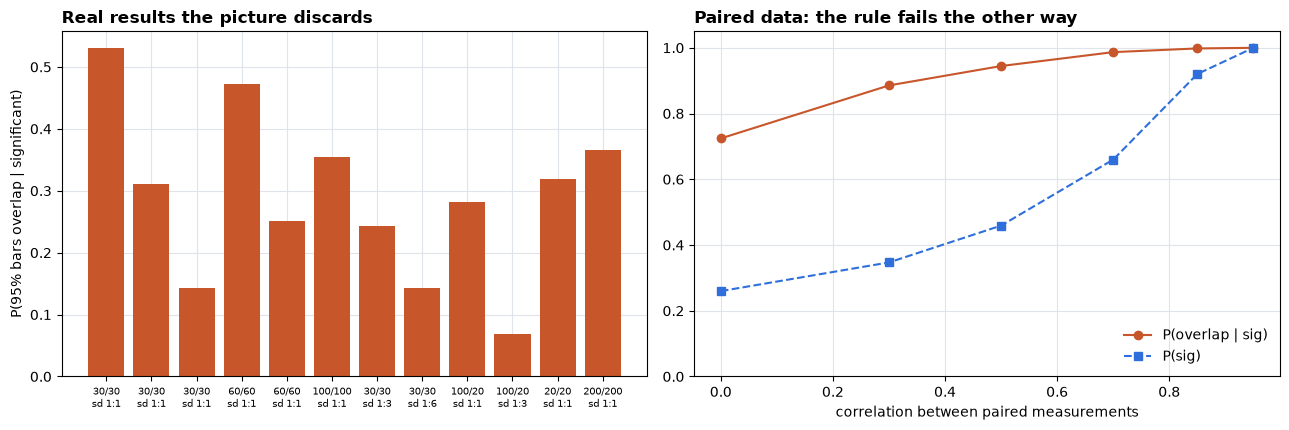

In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4))
lab = [f"{r['n1']}/{r['n2']}\nsd {r['sd1']:g}:{r['sd2']:g}" for r in dead]
a1.bar(range(len(dead)), [r["overlap_given_sig"] for r in dead], color="#c8562b")
a1.set_xticks(range(len(dead)))
a1.set_xticklabels(lab, fontsize=7)
a1.set_ylabel("P(95% bars overlap | significant)")
a1.set_title("Real results the picture discards", loc="left", fontweight="bold")
a2.plot(RHO_GRID, [r["overlap_given_sig"] for r in paired], "o-", color="#c8562b",
        label="P(overlap | sig)")
a2.plot(RHO_GRID, [r["sig"] for r in paired], "s--", color="#2f6fdb", label="P(sig)")
a2.set_xlabel("correlation between paired measurements")
a2.set_ylim(0, 1.05)
a2.legend(frameon=False, loc="lower right")
a2.set_title("Paired data: the rule fails the other way", loc="left", fontweight="bold")
for ax in (a1, a2):
    ax.grid(True, color="#dfe4ea")
    ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("notebook_chart.png", dpi=150)
plt.show()

## Summary

| | |
|---|---|
| **Matching level** | bars agree with `p < 0.05` at **83.4%**, not 95% (equal standard errors) |
| **Rule size** | "bars do not touch" is a **0.6%** test labelled 5% |
| **Dead zone** | up to **52%** of significant results have overlapping 95% bars |
| **Paired data** | at rho = 0.95, **99.99%** of rejections sit behind overlapping bars |
| **Wald bars** | exact coverage **0.33** at p = 0.02, n = 20 - and zero width on zero events |

The fix is a caption, not a correction: draw the bars at the matching level and say so, or draw
the interval for the **difference** - the estimate the question was about in the first place.

## Try your own

In [8]:
# Your chart: two means, their SEs, and the correlation between them (0 if independent groups).
# m1, m2, se1, se2, rho = 10.2, 11.0, 0.35, 0.40, 0.0
# d, z = abs(m2 - m1), 1.959964
# print("bars overlap:", d <= z * (se1 + se2))
# se_d = math.sqrt(se1**2 + se2**2 - 2 * rho * se1 * se2)
# print("p =", 2 * stats.norm.sf(d / se_d))
# print("draw bars at", f"{matching_level(se1, se2) * 100:.1f}%", "to make overlap mean p < 0.05")
print("uncomment to explore")

uncomment to explore


---

**Built by Phoebe Fu** - one mini product a day. [Repo](https://github.com/phoebefu6/phoebe-the-builder) ·
[This build](data-science-cookbook/ci-overlap-fallacy)

Streamlit version, where you drag two bars around and watch the picture and the test disagree:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Sibling builds: [`effect-size-reader`](../effect-size-reader) (an estimate),
[`p-value-dance`](../p-value-dance) (p under replay),
[`prediction-interval`](../prediction-interval) (a different interval, about a future observation).